In [10]:
#For my models i relied only on validation and didnt use any final testing data to test seperately vald_dataset can be used as its alternate anyway
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D,AveragePooling2D,Input,Rescaling
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
train_dataset= tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/animal_data',
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

vald_dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/animal_data',
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 1946 files belonging to 15 classes.
Using 1363 files for training.
Found 1946 files belonging to 15 classes.
Using 583 files for validation.


In [13]:
#structure of model strides used initially in order to cut down size significantly to reduce training time and data size going through
#After that its just the same pattern repeated just convoluting and pooling with dropout repeatedly
model5_var = Sequential()

model5_var.add(tf.keras.Input(shape=(224,224,3))),

model5_var.add(Conv2D(filters=32, kernel_size=(3,3) , strides=2, padding='same',activation='relu'))
model5_var.add(BatchNormalization())
model5_var.add(Conv2D(32, 3, strides=2, padding='same'))
model5_var.add(BatchNormalization())

model5_var.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu' ))
model5_var.add(BatchNormalization())
model5_var.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu' ))
model5_var.add(BatchNormalization())
model5_var.add(MaxPooling2D(pool_size=(2, 2)))
model5_var.add(Dropout(rate=0.2))

model5_var.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'))
model5_var.add(BatchNormalization())
model5_var.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', ))
model5_var.add(BatchNormalization())
model5_var.add(MaxPooling2D(pool_size=(2, 2)))
model5_var.add(Dropout(rate=0.3))

model5_var.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu',))
model5_var.add(BatchNormalization())
model5_var.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu',))
model5_var.add(BatchNormalization())
model5_var.add(MaxPooling2D(pool_size=(2, 2)))
model5_var.add(Dropout(rate=0.4))

model5_var.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', ))
model5_var.add(BatchNormalization())
model5_var.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', ))
model5_var.add(BatchNormalization())
model5_var.add(MaxPooling2D(pool_size=(2, 2)))
model5_var.add(Dropout(rate=0.5))

model5_var.add(Flatten())
model5_var.add(Dense(200, activation='relu'))
model5_var.add(Dense(15, activation='softmax'))


In [31]:
#optimizer adam used since it is used commonly
optimizer = Adam(learning_rate=0.001)
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=0.00001)

early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)


model5_var.compile(optimizer=optimizer,
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

In [30]:
model5_var.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 128)      │             

 Total params: 1,658,863 (6.33 MB)

 Trainable params: 1,656,815 (6.32 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [24]:
model5_var.fit(train_dataset,validation_data=vald_dataset,epochs=2,callbacks=[reduce_lr, early_stopping],verbose=1)


Epoch 1/2
43/43 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.7332 - loss: 0.8192 - val_accuracy: 0.5609 - val_loss: 1.6870 - learning_rate: 0.0010
Epoch 2/2
43/43 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.7480 - loss: 0.8326 - val_accuracy: 0.5575 - val_loss: 1.9137 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


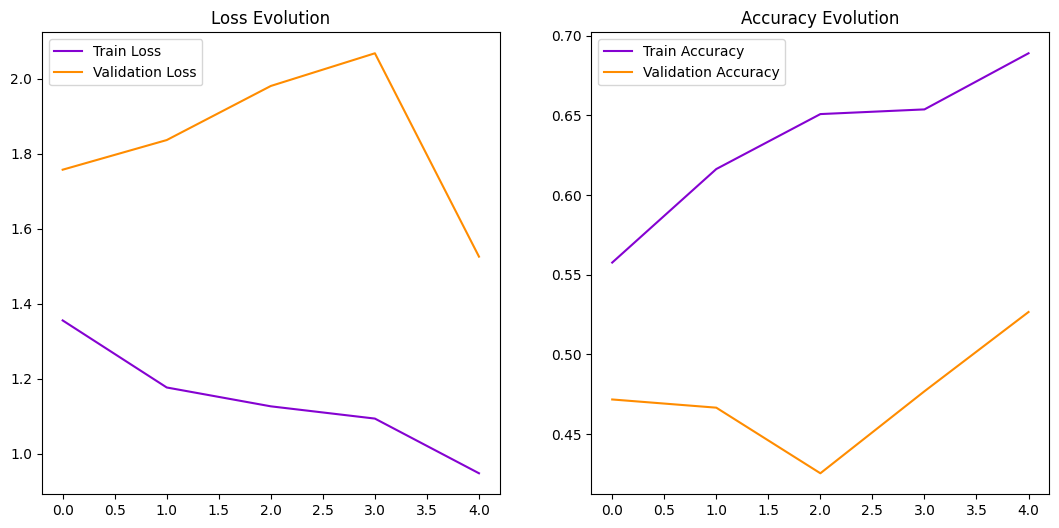

In [23]:
plt.figure(figsize=(13,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model5_var.history.history['loss'], label='Train Loss', color='#8502d1')
plt.plot(model5_var.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model5_var.history.history['accuracy'], label='Train Accuracy', color='#8502d1')
plt.plot(model5_var.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

In [21]:
model5_var.save("/content/drive/MyDrive/animal_classifier5_var.keras")